# 전처리 및 변수 설정

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

# ==========================================
# [실험 설정 구간] 모든 하이퍼파라미터 통합 ㅋ
# ==========================================
DATA_PATH = '../CMAPSSData/'
CONFIG = {
    'DATA_ID': 'FD001',
    'RUL_CAP': 125,
    'GAUSS_SIGMA': 2,
    'RANDOM_STATE': 42,
    'TEST_SIZE': 0.2,
    'SCALER_TYPE': 'minmax',  # minmax , Standard
    
    # 사용할 센서 직접 지정 (상수 센서 자동 감지 대신 사용 ㅋ)
    'BASE_SENSORS': ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 
                     's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21'],
    'SETTING_FEATURES': ['setting_1', 'setting_2', 'setting_3'],

    # 파생변수 설정
    'USE_MA': False,   'WIN_MA': 5,
    'USE_STD': False,  'WIN_STD': 5,  
    'USE_DIFF': False, 'PER_DIFF': 1,
    'USE_EMA': False,  'SPAN_EMA': 5,
    'USE_LAG': False,  'LAG_STEP': 1,
}

# ---------------------------------------------------------
# [1] 데이터 로드 및 초기 전처리 (Capping & 상수 제거)
# ---------------------------------------------------------
def load_and_basic_prep(config):
    # 전체 컬럼 정의
    cols = ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3'] + [f's_{i}' for i in range(1, 22)]
    
    # 데이터 로드
    train = pd.read_csv(f"{DATA_PATH}train_{config['DATA_ID']}.txt", sep='\s+', header=None, names=cols)
    test = pd.read_csv(f"{DATA_PATH}test_{config['DATA_ID']}.txt", sep='\s+', header=None, names=cols)
    y_test_final = pd.read_csv(f"{DATA_PATH}RUL_{config['DATA_ID']}.txt", sep='\s+', header=None, names=['RUL'])['RUL'].values

    # RUL 생성 및 Capping
    train['max_cycle'] = train.groupby('unit_nr')['time_cycles'].transform('max')
    train['RUL'] = (train['max_cycle'] - train['time_cycles']).clip(upper=config['RUL_CAP'])
    train.drop(columns=['max_cycle'], inplace=True)

    # 명시적으로 선택한 컬럼만 유지 (unit_nr, time_cycles, RUL + 선택 센서 + 세팅값 ㅋ)
    keep_cols = ['unit_nr', 'time_cycles'] + config['SETTING_FEATURES'] + config['BASE_SENSORS']
    
    # Train은 RUL 포함, Test는 RUL 제외하고 선택
    train = train[keep_cols + ['RUL']]
    test = test[keep_cols]
    
    print(f"✅ 센서 선택 완료: {config['BASE_SENSORS']}")
    print(f"✅ 유지된 컬럼 총 {len(train.columns)}개 (RUL 포함)")
    
    return train, test, y_test_final

# 실행 ㅋ
df_train, df_test, y_test = load_and_basic_prep(CONFIG)

# ---------------------------------------------------------
# [2] 가우시안 스무딩 (Team Style)
# ---------------------------------------------------------
def apply_gaussian_smoothing(df, sigma):
    if sigma <= 0: return df.copy()
    df = df.copy().sort_values(['unit_nr', 'time_cycles']).reset_index(drop=True)
    sensors = [c for c in df.columns if c.startswith('s_')]
    
    for uid in df['unit_nr'].unique():
        mask = df['unit_nr'] == uid
        for col in sensors:
            arr = df.loc[mask, col].to_numpy(dtype=np.float32)
            df.loc[mask, col] = gaussian_filter1d(arr, sigma=sigma, mode='nearest')
    return df

df_train = apply_gaussian_smoothing(df_train, CONFIG['GAUSS_SIGMA'])
df_test = apply_gaussian_smoothing(df_test, CONFIG['GAUSS_SIGMA'])
print(f"✅ 가우시안 스무딩 완료 (Sigma: {CONFIG['GAUSS_SIGMA']})")

# ---------------------------------------------------------
# [3] 데이터 분할 (Train / Val)
# ---------------------------------------------------------
unit_ids = df_train['unit_nr'].unique()
train_units, val_units = train_test_split(unit_ids, test_size=CONFIG['TEST_SIZE'], random_state=CONFIG['RANDOM_STATE'])

train_set = df_train[df_train['unit_nr'].isin(train_units)].copy()
val_set = df_train[df_train['unit_nr'].isin(val_units)].copy()
test_set = df_test.copy()

# ---------------------------------------------------------
# [4] 정규화 (Base Sensors + Settings)
# ---------------------------------------------------------
base_sensors = sorted([c for c in df_train.columns if c.startswith('s_')], key=lambda x: int(x.split('_')[1]))
base_plus_setting = base_sensors + CONFIG['SETTING_FEATURES']

if CONFIG['SCALER_TYPE'] == 'minmax':
    scaler = MinMaxScaler()
else:
    scaler = StandardScaler()

train_set[base_plus_setting] = scaler.fit_transform(train_set[base_plus_setting])
val_set[base_plus_setting] = scaler.transform(val_set[base_plus_setting])
test_set[base_plus_setting] = scaler.transform(test_set[base_plus_setting])
print(f" 정규화 완료 ({CONFIG['SCALER_TYPE']})")

# ---------------------------------------------------------
# [5] 파생변수 생성 (정규화된 데이터 기반)
# ---------------------------------------------------------
def add_features_final(df, features, config):
    df_res = df.copy()
    for col in features:
        group = df_res.groupby('unit_nr')[col]

        if config['USE_MA']:
            df_res[f'{col}_ma'] = group.transform(lambda x: x.rolling(config['WIN_MA'], min_periods=1).mean())
        
        if config['USE_STD']:
            df_res[f'{col}_std'] = group.transform(lambda x: x.rolling(config['WIN_STD'], min_periods=1).std().fillna(0))
            
        if config['USE_DIFF']:
            df_res[f'{col}_diff'] = group.transform(lambda x: x.diff(config['PER_DIFF']).fillna(0))
            
        if config['USE_EMA']:
            df_res[f'{col}_ema'] = group.transform(lambda x: x.ewm(span=config['SPAN_EMA'], adjust=False).mean())
            
        if config['USE_LAG']:
            df_res[f'{col}_lag'] = group.transform(lambda x: x.shift(config['LAG_STEP']).bfill())
                
    return df_res

train_set = add_features_final(train_set, base_sensors, CONFIG)
val_set = add_features_final(val_set, base_sensors, CONFIG)
test_set = add_features_final(test_set, base_sensors, CONFIG)

# 최종 피처 리스트 구성 ㅋ
X_features_full = base_sensors + CONFIG['SETTING_FEATURES']
if CONFIG['USE_MA']:   X_features_full += [f'{c}_ma' for c in base_sensors]
if CONFIG['USE_STD']:  X_features_full += [f'{c}_std' for c in base_sensors]
if CONFIG['USE_DIFF']: X_features_full += [f'{c}_diff' for c in base_sensors]
if CONFIG['USE_EMA']:  X_features_full += [f'{c}_ema' for c in base_sensors]
if CONFIG['USE_LAG']:  X_features_full += [f'{c}_lag' for c in base_sensors]

# 최종 변수 할당
X_train, y_train = train_set[X_features_full], train_set['RUL']
X_val, y_val = val_set[X_features_full], val_set['RUL']
X_test = test_set.groupby('unit_nr').last()[X_features_full] # 테스트는 마지막 시점만 ㅋ

print(f"\n 전처리 파이프라인 완료!")
print(f" 최종 피처 수: {len(X_features_full)}개")
print(f" 데이터 형태: X_train{X_train.shape}, X_test{X_test.shape}")
print(f" X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")
print(f" X_train: {y_train.shape}, X_val: {y_val.shape}, X_test: {y_test.shape}")

<>:42: SyntaxWarning: invalid escape sequence '\s'
<>:43: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\s'
<>:42: SyntaxWarning: invalid escape sequence '\s'
<>:43: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\s'
C:\Users\yesyo\AppData\Local\Temp\ipykernel_50892\2109723533.py:42: SyntaxWarning: invalid escape sequence '\s'
  train = pd.read_csv(f"{DATA_PATH}train_{config['DATA_ID']}.txt", sep='\s+', header=None, names=cols)
C:\Users\yesyo\AppData\Local\Temp\ipykernel_50892\2109723533.py:43: SyntaxWarning: invalid escape sequence '\s'
  test = pd.read_csv(f"{DATA_PATH}test_{config['DATA_ID']}.txt", sep='\s+', header=None, names=cols)
C:\Users\yesyo\AppData\Local\Temp\ipykernel_50892\2109723533.py:44: SyntaxWarning: invalid escape sequence '\s'
  y_test_final = pd.read_csv(f"{DATA_PATH}RUL_{config['DATA_ID']}.txt", sep='\s+', header=None, names=['RUL'])['RUL'].values
C:\Users\yesyo\AppData\Local\

✅ 센서 선택 완료: ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
✅ 유지된 컬럼 총 20개 (RUL 포함)


C:\Users\yesyo\AppData\Local\Temp\ipykernel_50892\2109723533.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[392.17642 392.11795 391.93655 391.69623 391.5161  391.4609  391.48407
 391.48898 391.43274 391.35953 391.34018 391.39062 391.45013 391.43777
 391.3329  391.20142 391.14267 391.21512 391.411   391.68246 391.9737
 392.22977 392.39252 392.4173  392.3117  392.1463  392.01035 391.9618
 392.0214  392.1852  392.41766]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[mask, col] = gaussian_filter1d(arr, sigma=sigma, mode='nearest')


✅ 가우시안 스무딩 완료 (Sigma: 2)
 정규화 완료 (minmax)

 전처리 파이프라인 완료!
 최종 피처 수: 17개
 데이터 형태: X_train(16561, 17), X_test(100, 17)
 X_train: (16561, 17), X_val: (4070, 17), X_test: (100, 17)
 X_train: (16561,), X_val: (4070,), X_test: (100,)


In [42]:
# 생성된 모든 피처 리스트 출력 ㅋ
print(f"총 피처 수: {len(X_train.columns)}개")
print("-" * 30)
for i, col in enumerate(X_train.columns):
    print(f"{i+1:03d}. {col}")

# 데이터 프레임의 상위 5행을 통해 값도 살짝 확인 ㅋ
# display(X_train.head()) # 주피터 노트북이라면 이 코드가 더 보기 편합니다

총 피처 수: 17개
------------------------------
001. s_2
002. s_3
003. s_4
004. s_7
005. s_8
006. s_9
007. s_11
008. s_12
009. s_13
010. s_14
011. s_15
012. s_17
013. s_20
014. s_21
015. setting_1
016. setting_2
017. setting_3


In [36]:
import numpy as np
from sklearn.metrics import mean_squared_error

def calculate_nasa_score(y_true, y_pred):
    """C-MAPSS 전용 NASA Score 계산 함수 ㅋ"""
    diff = y_pred - y_true
    # 조기 예측(diff < 0)보다 늦은 예측(diff > 0)에 더 큰 패널티 부여 
    score = np.where(diff < 0, np.exp(-diff/13)-1, np.exp(diff/10)-1)
    return np.sum(score)

def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    score = calculate_nasa_score(y_true, y_pred)
    print(f"[{model_name}] 평가 결과")
    print(f" RMSE: {rmse:.4f}")
    print(f" NASA Score: {score:.4f}")
    return rmse, score

# 예시 모델

In [35]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Linear Regression

In [6]:
# 가장 기본이 되는 선형 회귀 모델 ㅋ
lr_p = {'fit_intercept': True}
model_lr = LinearRegression(**lr_p)
model_lr.fit(X_train, y_train)
p_lr = model_lr.predict(X_test)

# 평가 및 저장 (시각화를 위해 p_latest에 할당)
lr_rmse, lr_score = evaluate_model(y_test, p_lr, "Linear Regression")
p_latest, latest_name = p_lr, "Linear Regression"

[Linear Regression] 평가 결과
 RMSE: 21.2920
 NASA Score: 1071.3751


# Ridge Regression

In [45]:
# L2 규제로 과적합을 방지하는 Ridge ㅋ
ridge_p = {'alpha': 0.5, 'random_state': CONFIG['RANDOM_STATE']}
model_ridge = Ridge(**ridge_p)
model_ridge.fit(X_train, y_train)
p_ridge = model_ridge.predict(X_test)

ridge_rmse, ridge_score = evaluate_model(y_test, p_ridge, "Ridge")
p_latest, latest_name = p_ridge, "Ridge"

[Ridge] 평가 결과
 RMSE: 22.2729
 NASA Score: 1516.4786


# Lasso Regression

In [8]:
# L1 규제로 불필요한 피처를 0으로 만드는 Lasso ㅋ
lasso_p = {'alpha': 0.01, 'random_state': CONFIG['RANDOM_STATE']}
model_lasso = Lasso(**lasso_p)
model_lasso.fit(X_train, y_train)
p_lasso = model_lasso.predict(X_test)

lasso_rmse, lasso_score = evaluate_model(y_test, p_lasso, "Lasso")
p_latest, latest_name = p_lasso, "Lasso"

[Lasso] 평가 결과
 RMSE: 21.7631
 NASA Score: 1296.9542


c:\Users\yesyo\sparta_project_4_team16\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.505e+04, tolerance: 2.874e+03
  model = cd_fast.enet_coordinate_descent(


# ElasticNet

In [9]:
from lightgbm import LGBMRegressor

# 모델 학습
lgb_model = LGBMRegressor(n_estimators=100, learning_rate=0.05, num_leaves=31, random_state=42)
lgb_model.fit(X_train, y_train, 
              eval_set=[(X_val, y_val)], 
              eval_metric='rmse',
              callbacks=None) # 시각화는 아래 통합 섹션에서 진행 ㅋ

# 예측 및 평가
y_pred_lgb = lgb_model.predict(X_test)
lgb_rmse, lgb_score = evaluate_model(y_test, y_pred_lgb, "LightGBM")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006381 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20501
[LightGBM] [Info] Number of data points in the train set: 16561, number of used features: 100
[LightGBM] [Info] Start training from score 86.958819
[LightGBM] 평가 결과
 RMSE: 18.9012
 NASA Score: 1094.6429


# XGBoost

In [39]:
# 강력한 성능의 Gradient Boosting XGBoost ㅋ
xgb_p = {
    'n_estimators': 100,
    'learning_rate': 0.05,
    'max_depth': 5,
    'random_state': CONFIG['RANDOM_STATE'],
    'tree_method': 'hist',
    'n_jobs': -1
}
model_xgb = XGBRegressor(**xgb_p)
model_xgb.fit(X_train, y_train)
p_xgb = model_xgb.predict(X_test)

xgb_rmse, xgb_score = evaluate_model(y_test, p_xgb, "XGBoost")
p_latest, latest_name = p_xgb, "XGBoost"

[XGBoost] 평가 결과
 RMSE: 18.3560
 NASA Score: 616.8097


# LightGBM

In [38]:
# 속도와 성능을 모두 잡은 LightGBM ㅋ
lgbm_p = {
    'n_estimators': 100,
    'learning_rate': 0.05,
    'max_depth': 4,
    'num_leaves': 15,
    'random_state': CONFIG['RANDOM_STATE'],
    'verbosity': -1,
    'n_jobs': -1
}
model_lgbm = LGBMRegressor(**lgbm_p)
model_lgbm.fit(X_train, y_train)
p_lgbm = model_lgbm.predict(X_test)

lgbm_rmse, lgbm_score = evaluate_model(y_test, p_lgbm, "LightGBM")
p_latest, latest_name = p_lgbm, "LightGBM"

[LightGBM] 평가 결과
 RMSE: 18.2614
 NASA Score: 632.1168


# Random Forest

In [40]:
# 앙상블의 정석 Random Forest ㅋ
rf_p = {
    'n_estimators': 100,
    'max_depth': 12,
    'random_state': CONFIG['RANDOM_STATE'],
    'n_jobs': -1
}
model_rf = RandomForestRegressor(**rf_p)
model_rf.fit(X_train, y_train)
p_rf = model_rf.predict(X_test)

rf_rmse, rf_score = evaluate_model(y_test, p_rf, "Random Forest")
p_latest, latest_name = p_rf, "Random Forest"

[Random Forest] 평가 결과
 RMSE: 19.1787
 NASA Score: 723.4489


# 최신 실행 모델 결과 시각화

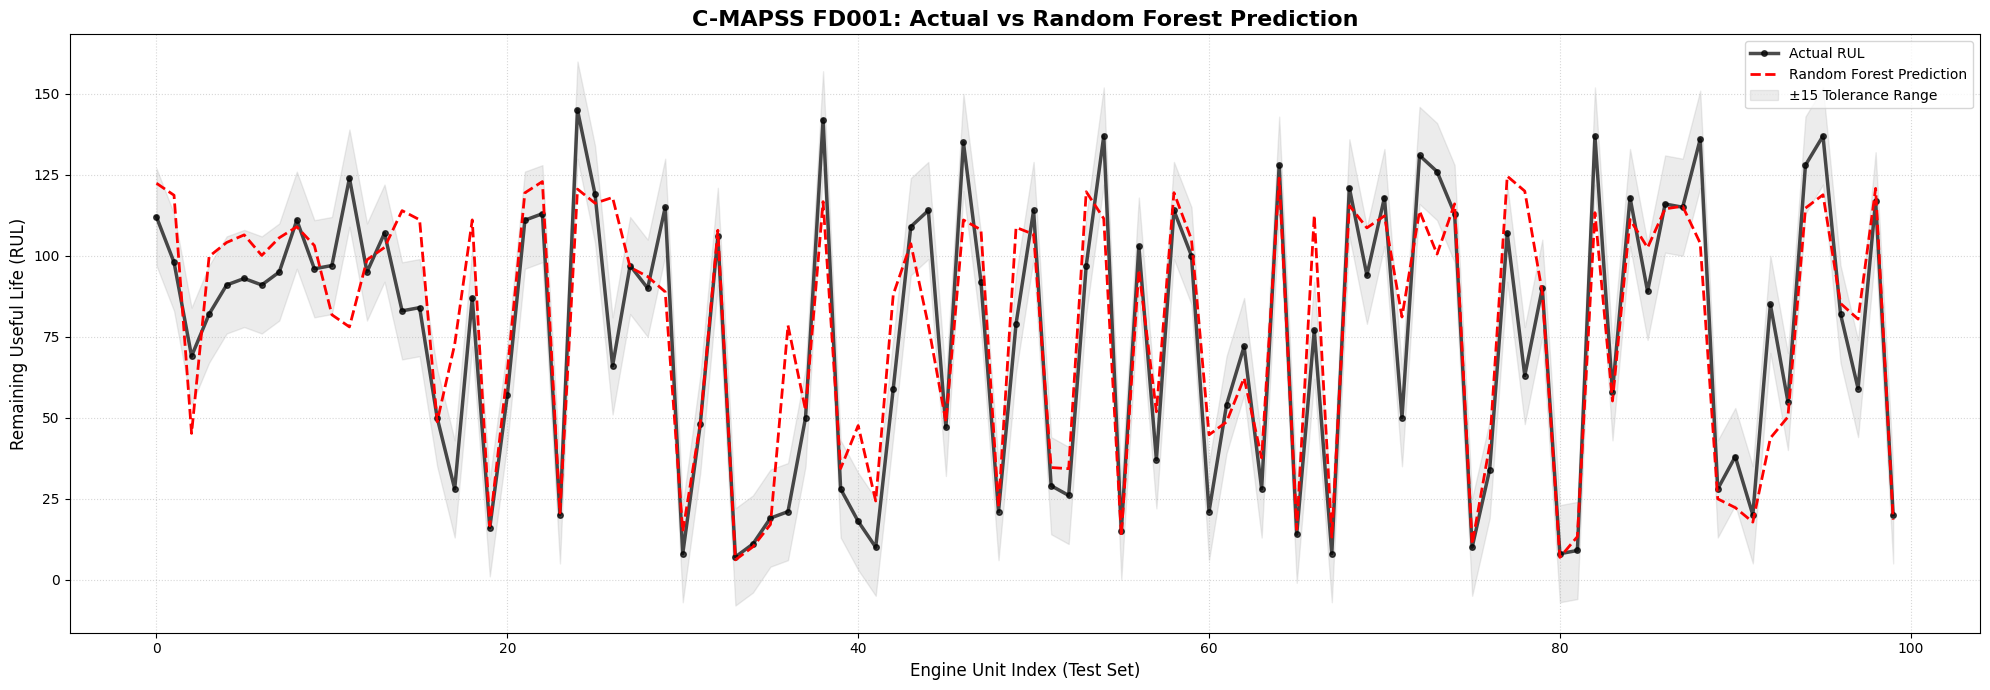

In [13]:
# 방금 실행한 모델의 예측값을 실제값과 비교합니다 ㅋ
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 7))

# 1. 실제 값 (정답)
plt.plot(y_test, label='Actual RUL', color='black', linewidth=2.5, marker='o', markersize=4, alpha=0.7)

# 2. 최신 모델 예측값
plt.plot(p_latest, label=f'{latest_name} Prediction', linestyle='--', color='red', linewidth=2)

# 제목 및 라벨
plt.title(f'C-MAPSS FD001: Actual vs {latest_name} Prediction', fontsize=16, fontweight='bold')
plt.xlabel('Engine Unit Index (Test Set)', fontsize=12)
plt.ylabel('Remaining Useful Life (RUL)', fontsize=12)

# 오차 허용 범위 (±15) 시각화 ㅋ
plt.fill_between(range(len(y_test)), y_test-15, y_test+15, color='gray', alpha=0.15, label='±15 Tolerance Range')

plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# 실제값 vs 예측값 비교 시각화

C:\Users\yesyo\AppData\Local\Temp\ipykernel_50892\471859133.py:42: UserWarning: Glyph 50644 (\N{HANGUL SYLLABLE EN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yesyo\AppData\Local\Temp\ipykernel_50892\471859133.py:42: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yesyo\AppData\Local\Temp\ipykernel_50892\471859133.py:42: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yesyo\AppData\Local\Temp\ipykernel_50892\471859133.py:42: UserWarning: Glyph 45937 (\N{HANGUL SYLLABLE DEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yesyo\AppData\Local\Temp\ipykernel_50892\471859133.py:42: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yesyo\AppData\Local\Temp\ipykernel_50892\471859133.py:42: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s

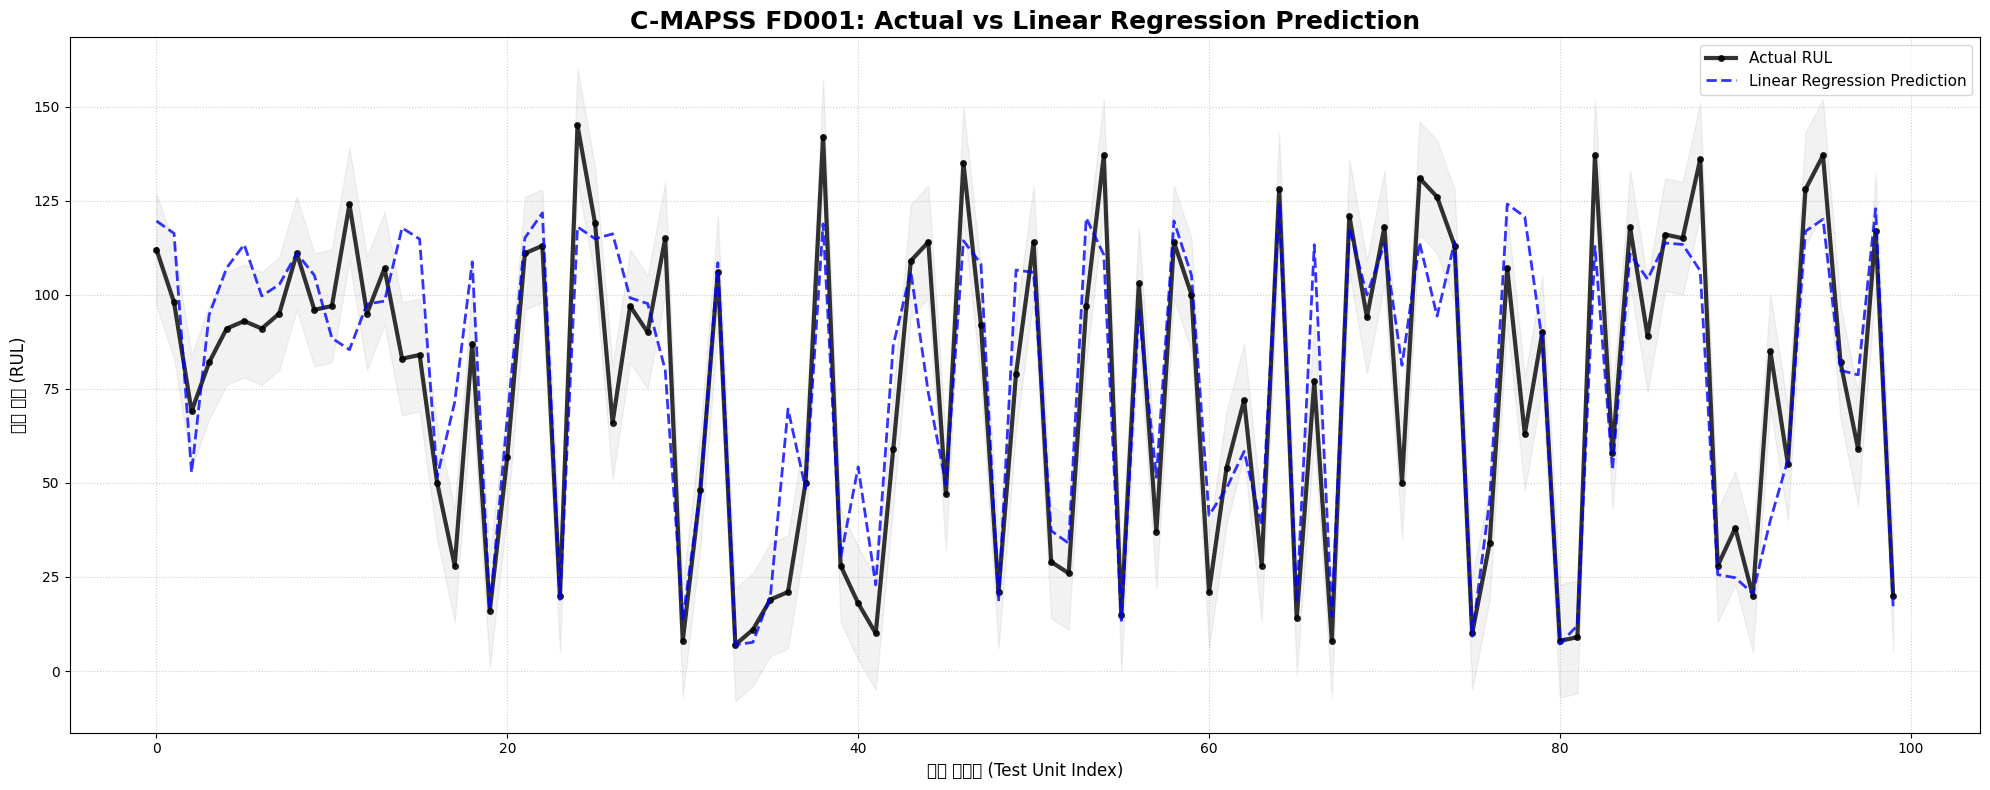

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))

# 1. 실제 값 (정답)
plt.plot(y_test, 
         label='Actual RUL', 
         color='black', 
         linewidth=3, 
         marker='o', 
         markersize=4, 
         alpha=0.8)

# 2. Linear Regression 예측값
plt.plot(y_pred_lgb, 
         label='Linear Regression Prediction', 
         linestyle='--', 
         color='blue',
         linewidth=2,
         alpha=0.8)

# 제목 및 라벨
plt.title('C-MAPSS FD001: Actual vs Linear Regression Prediction', 
          fontsize=18, fontweight='bold')
plt.xlabel('엔진 인덱스 (Test Unit Index)', fontsize=12)
plt.ylabel('잔여 수명 (RUL)', fontsize=12)

# 범례
plt.legend(loc='upper right', fontsize=11)

# 격자
plt.grid(True, linestyle=':', alpha=0.6)

# 오차 허용 범위 (±15)
plt.fill_between(range(len(y_test)), 
                 y_test-15, 
                 y_test+15, 
                 color='gray', 
                 alpha=0.1,
                 label='±15 Tolerance')

plt.tight_layout()
plt.show()

In [15]:
import optuna
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

# ---------------------------------------------------------
# [필수] NASA Scoring Function 정의 ㅋ
# ---------------------------------------------------------
def nasa_score(y_true, y_pred):
    """
    CMAPSS용 NASA Scoring Function
    d < 0 (조기 예측): exp(-d/10) - 1
    d > 0 (지연 예측): exp(d/13) - 1 (패널티 더 높음 ㅋ)
    """
    d = y_pred - y_true
    score = np.where(d < 0, np.exp(-d/10) - 1, np.exp(d/13) - 1)
    return np.sum(score)

# 결과 저장을 위한 딕셔너리
best_params_dict = {}

# ---------------------------------------------------------
# 모델별 Objective 함수 정의 (RMSE & NASA Score 실시간 출력) ㅋ
# ---------------------------------------------------------

# 1. Linear Regression
def objective_lr(trial):
    model = LinearRegression()
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    n_score = nasa_score(y_val.values, preds)
    
    print(f"   [Trial {trial.number}] RMSE: {rmse:.4f} | NASA Score: {n_score:.2f}")
    return rmse

# 2. Ridge
def objective_ridge(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 100.0, log=True)
    model = Ridge(alpha=alpha, random_state=CONFIG['RANDOM_STATE'])
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    n_score = nasa_score(y_val.values, preds)
    
    print(f"   [Trial {trial.number}] RMSE: {rmse:.4f} | NASA Score: {n_score:.2f}")
    return rmse

# 3. Lasso
def objective_lasso(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 100.0, log=True)
    model = Lasso(alpha=alpha, random_state=CONFIG['RANDOM_STATE'])
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    n_score = nasa_score(y_val.values, preds)
    
    print(f"   [Trial {trial.number}] RMSE: {rmse:.4f} | NASA Score: {n_score:.2f}")
    return rmse

# 4. ElasticNet
def objective_elastic(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 100.0, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=CONFIG['RANDOM_STATE'])
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    n_score = nasa_score(y_val.values, preds)
    
    print(f"   [Trial {trial.number}] RMSE: {rmse:.4f} | NASA Score: {n_score:.2f}")
    return rmse

# 5. Random Forest
def objective_rf(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'random_state': CONFIG['RANDOM_STATE'],
        'n_jobs': -1
    }
    model = RandomForestRegressor(**param)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    n_score = nasa_score(y_val.values, preds)
    
    print(f"   [Trial {trial.number}] RMSE: {rmse:.4f} | NASA Score: {n_score:.2f}")
    return rmse

# 6. XGBoost
def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'tree_method': 'hist',
        'random_state': CONFIG['RANDOM_STATE']
    }
    model = XGBRegressor(**param)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    n_score = nasa_score(y_val.values, preds)
    
    print(f"   [Trial {trial.number}] RMSE: {rmse:.4f} | NASA Score: {n_score:.2f}")
    return rmse

# 7. LightGBM
def objective_lgbm(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 2, 256),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'verbosity': -1,
        'random_state': CONFIG['RANDOM_STATE']
    }
    model = LGBMRegressor(**param)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    n_score = nasa_score(y_val.values, preds)
    
    print(f"   [Trial {trial.number}] RMSE: {rmse:.4f} | NASA Score: {n_score:.2f}")
    return rmse

# ==========================================
# [최적화 실행 루프]
# ==========================================
objectives = {
    'Linear': objective_lr, 'Ridge': objective_ridge, 'Lasso': objective_lasso,
    'ElasticNet': objective_elastic, 'RF': objective_rf, 'XGB': objective_xgb, 'LGBM': objective_lgbm
}

for name, obj_func in objectives.items():
    print(f"\n🚀 {name} 최적화 시작...")
    # 로그 출력을 깔끔하게 하기 위해 optuna 기본 로그 수준 조절 ㅋ
    optuna.logging.set_verbosity(optuna.logging.WARNING) 
    
    study = optuna.create_study(direction='minimize')
    study.optimize(obj_func, n_trials=20) 
    
    best_params_dict[name] = study.best_params
    print(f"✅ {name} 최적화 완료! Best RMSE: {study.best_value:.4f}")

print("\n" + "="*60)
print(" 모든 모델의 최적 파라미터 탐색 및 NASA Score 확인 완료! ㅋ")
print("="*60)


🚀 Linear 최적화 시작...
   [Trial 0] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 1] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 2] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 3] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 4] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 5] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 6] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 7] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 8] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 9] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 10] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 11] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 12] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 13] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 14] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 15] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 16] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 17] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 18] RMSE: 19.3820 | NASA Score: 30244.73
   [Trial 19] RMSE: 1

c:\Users\yesyo\sparta_project_4_team16\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.131e+04, tolerance: 2.874e+03
  model = cd_fast.enet_coordinate_descent(


   [Trial 0] RMSE: 20.0220 | NASA Score: 32074.99


c:\Users\yesyo\sparta_project_4_team16\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.508e+03, tolerance: 2.874e+03
  model = cd_fast.enet_coordinate_descent(


   [Trial 1] RMSE: 20.3376 | NASA Score: 33930.72
   [Trial 2] RMSE: 23.6480 | NASA Score: 48903.51
   [Trial 3] RMSE: 24.8764 | NASA Score: 52099.08


...

   [Trial 16] RMSE: 20.2666 | NASA Score: 33553.76


c:\Users\yesyo\sparta_project_4_team16\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.948e+05, tolerance: 2.874e+03
  model = cd_fast.enet_coordinate_descent(


   [Trial 17] RMSE: 20.0055 | NASA Score: 32043.51


c:\Users\yesyo\sparta_project_4_team16\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.224e+06, tolerance: 2.874e+03
  model = cd_fast.enet_coordinate_descent(


   [Trial 18] RMSE: 19.9991 | NASA Score: 32027.52
   [Trial 19] RMSE: 20.2108 | NASA Score: 33579.74
✅ ElasticNet 최적화 완료! Best RMSE: 19.8401

🚀 RF 최적화 시작...
   [Trial 0] RMSE: 16.2871 | NASA Score: 20162.41
   [Trial 1] RMSE: 17.6185 | NASA Score: 24801.86
   [Trial 2] RMSE: 16.3547 | NASA Score: 19642.27
   [Trial 3] RMSE: 16.3303 | NASA Score: 19600.19
   [Trial 4] RMSE: 16.3272 | NASA Score: 20184.81
   [Trial 5] RMSE: 16.3641 | NASA Score: 19762.11
   [Trial 6] RMSE: 16.2750 | NASA Score: 20076.71
   [Trial 7] RMSE: 16.3252 | NASA Score: 20320.26
   [Trial 8] RMSE: 18.9165 | NASA Score: 32443.36
   [Trial 9] RMSE: 16.2736 | NASA Score: 19951.47
   [Trial 10] RMSE: 16.3493 | NASA Score: 20557.75
   [Trial 11] RMSE: 16.2644 | NASA Score: 19867.06
   [Trial 12] RMSE: 16.2957 | NASA Score: 20005.64
   [Trial 13] RMSE: 16.2793 | NASA Score: 19860.07
   [Trial 14] RMSE: 16.3132 | NASA Score: 20324.08
   [Trial 15] RMSE: 16.2766 | NASA Score: 19864.13
   [Trial 16] RMSE: 16.2954 | NASA S

In [17]:
# 최적화된 파라미터 확인 예시 ㅋ
import pprint
pprint.pprint(best_params_dict)

{'ElasticNet': {'alpha': 0.0011031157521679594, 'l1_ratio': 0.7698391053569069},
 'LGBM': {'lambda_l1': 6.581085980687492,
          'lambda_l2': 1.0262453967012054e-06,
          'learning_rate': 0.07331130347699083,
          'max_depth': 3,
          'n_estimators': 274,
          'num_leaves': 213},
 'Lasso': {'alpha': 0.002285157306815353},
 'Linear': {},
 'RF': {'max_depth': 11, 'min_samples_split': 13, 'n_estimators': 298},
 'Ridge': {'alpha': 0.0031531346643415285},
 'XGB': {'colsample_bytree': 0.7665966150914315,
         'learning_rate': 0.01631651345622754,
         'max_depth': 4,
         'n_estimators': 517,
         'subsample': 0.8328206428645647}}
